In [1]:

from voy_font import load_voynich_font, voynich_style, voynich_text, voyn_print

In [2]:
import json
import os

os.environ["BLT_SUPPRESS_ATTN_ERROR"] = "1"
HF_REPO = "facebook/blt-entropy"

from voynpy.corpora import stars_df
from voynpy.corpora import vms_unicode_bmp
from vms_uprep import prepare, stack_lines

import torch
import torch.nn.functional as F
from huggingface_hub import hf_hub_download

from bytelatent.transformer import LMTransformer, LMTransformerArgs


/workspace/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.11.0+cu130)
    Python  3.10.19 (you have 3.12.3)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


In [3]:
lines = prepare(vms_unicode_bmp.df, {
    "start": {"folio": "1r", "par": 1, "line": 1},
    "end":   {"folio": "2v", "par": 1, "line": 3}
})

In [4]:
voyn_print(lines)

In [5]:
# Stack lines into a single string, with newlines between them
text_stack = stack_lines(lines, max_bytes=512)

In [6]:
len(text_stack)

11

In [7]:
def entropy(scores):
    """Compute per-token Shannon entropy from logits. Uses natural log."""
    log_probs = F.log_softmax(scores, dim=-1)
    probs = torch.exp(log_probs)
    p_log_p = log_probs * probs
    return -p_log_p.sum(dim=-1)

In [8]:
def load_entropy_model():
    """Load the BLT entropy model from HuggingFace Hub."""

    config_path = hf_hub_download(HF_REPO, "config.json")
    weights_path = hf_hub_download(HF_REPO, "model.safetensors")
    with open(config_path) as f:
        config = json.load(f)

    args_dict = config.get("args", config)
    torch.set_default_dtype(torch.bfloat16)
    model_args = LMTransformerArgs(**args_dict)
    model = LMTransformer(model_args)

    from safetensors.torch import load_file

    state_dict = load_file(weights_path)
    model.load_state_dict(state_dict, strict=False)

    model.attn_impl = "sdpa"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device).eval()
    for param in model.parameters():
        param.requires_grad = False

    param_count = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"[bold green]Loaded entropy model:[/] {param_count:.0f}M parameters ({device})")
    return model, model_args

In [9]:
def build_sliding_window_causal_mask(seq_len, window_size, device="cpu"):
    """Build a sliding window causal attention mask for sdpa."""
    # Create position indices
    rows = torch.arange(seq_len, device=device).unsqueeze(1)
    cols = torch.arange(seq_len, device=device).unsqueeze(0)
    # Causal: attend only to past positions; sliding window: at most window_size back
    mask = (rows >= cols) & (rows - cols < window_size)
    # sdpa expects float mask with -inf for masked positions
    attn_mask = torch.where(mask, 0.0, float("-inf"))
    return attn_mask

In [10]:
entropy_model, model_args = load_entropy_model()
device = next(entropy_model.parameters()).device

[bold green]Loaded entropy model:[/] 100M parameters (cpu)


In [11]:
# BLT vocab: [BOE=0, BOS=1, EOS=2, BPE=3, byte_0=4, ..., byte_255=259]
BLT_BYTE_OFFSET = 4
token_ids = [b + BLT_BYTE_OFFSET for b in text_stack[0].encode("utf-8")]
tokens = torch.tensor([token_ids], dtype=torch.long).to(device)

In [12]:
sliding_window = model_args.sliding_window or 512
attn_mask = build_sliding_window_causal_mask(len(token_ids), sliding_window, device=device)

In [13]:
with torch.no_grad():
    logits = entropy_model(tokens, mask=attn_mask)
    ent_tensor = entropy(logits)



In [14]:
ent_values = [e.item() for e in ent_tensor[0]]

raw_byte_ids = [b - BLT_BYTE_OFFSET for b in token_ids]

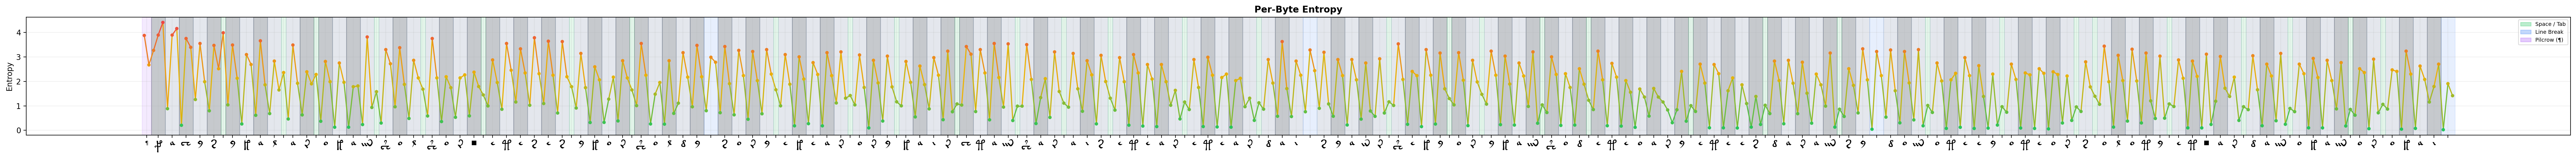

In [15]:
from voy_entropy_display import display_entropy

# After running the BLT entropy model:
display_entropy(text_stack[0], raw_byte_ids, ent_values, show_table=False)